# HW6 — Statistical baselines: ARIMA, ETS and state-space

## Why this notebook exists

Every notebook in this repository so far starts from machine learning. This one starts at the
*opposite* end of the complexity ladder, because the hardest part of an applied quant research
job is not fitting a bigger model — it is proving that a model beats nothing.

The vacancy brief for this role asks for three things that are conspicuously absent from
`HW1`–`HW5`:

| Requirement | Present in HW1–HW5? |
|---|---|
| ARIMA / ETS / state-space models | No |
| Honest comparison of simple vs complex models | No |
| Probabilistic forecasts with calibrated intervals | No |

So this notebook does three things:

1. **Establishes the benchmark honestly.** Stationarity tests, autocorrelation structure, and a
   proper AIC/BIC order search — on the *initial training window only*, never on the test set.
2. **Compares a model zoo on one protocol.** A zero-parameter **constant-mean forecast**, the
   random walk, ARIMA, three ETS variants and two state-space specifications, all evaluated with
   the same rolling one-step-ahead procedure, the same metric set, and a HAC-corrected
   Diebold-Mariano test. The constant is in the suite on purpose: without it, a result can look
   like a win while measuring nothing.
3. **Separates statistical significance from tradability.** The interesting question is not
   "did a model win" but "what exactly did it win, and is it worth anything". Significance,
   squared-error skill and tradable edge are three different objects, and the ranking against
   the two zero-parameter benchmarks is what settles all three.

### One correction that changed the headline

An earlier draft of this notebook reported that ARIMA/ETS models beat the random walk on daily
SPY returns by a large, significant margin, and used that to "correct" a claim in `HW2`. The
margin was real; the conclusion drawn from it was not.

The bug: `one_step_ahead` refits only every 21 bars, because re-estimating an ARIMA on each of 504
bars is slow. But the random walk and the constant have **no parameters**, so they were being
frozen for 21 days too — turning "tomorrow equals today" into "tomorrow equals today as of three
weeks ago". Any parameter-based model was then competing against a straw man.

Both zero-parameter baselines are now re-evaluated on **every bar**, which gives the incumbent the
best available treatment. The specific numbers are in the tables below; the point worth carrying
to `HW7` and `HW8` is the method: an edge over a badly implemented baseline is not an edge, and
the cheapest possible benchmark is the one most likely to be implemented wrongly.

## The single most important methodological choice

Model order and hyper-parameters are selected using AIC/BIC **on the first training slice only**.
They are then frozen. Re-selecting the order on every walk-forward step would let the test set
leak into the specification, and it is the single easiest way to manufacture a beautiful
backtest out of a worthless model.

In [1]:
import os
import sys
import time
import warnings
from itertools import product

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

warnings.filterwarnings("ignore")

# statsmodels raises these routinely on financial data: MLE on near-unit-root
# series frequently stalls without the optimum mattering, and a handful of the
# AIC grid cells legitimately fail to converge. Silence is a deliberate choice,
# not an oversight -- the convergence flag is checked explicitly where it does
# matter (see the residual diagnostics).
try:
    from statsmodels.tools.sm_exceptions import (
        ConvergenceWarning,
        EstimationWarning,
        ValueWarning,
    )

    warnings.filterwarnings("ignore", category=ConvergenceWarning)
    warnings.filterwarnings("ignore", category=EstimationWarning)
    warnings.filterwarnings("ignore", category=ValueWarning)
except ImportError:
    pass
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)

# Make the shared, unit-tested research utilities importable from the notebook directory.
NOTEBOOK_DIR = os.path.dirname(os.path.abspath("__file__")) if "__file__" in dir() else os.getcwd()
if NOTEBOOK_DIR not in sys.path:
    sys.path.insert(0, NOTEBOOK_DIR)

from mlfin_core import (
    split_conformal_interval,
    conformal_coverage,
    load_ohlcv,
    synthetic_ohlcv,
)
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.statespace.structural import UnobservedComponents
from statsmodels.tsa.exponential_smoothing.ets import ETSModel
from statsmodels.tsa.stattools import acf, pacf, adfuller, kpss
from statsmodels.stats.diagnostic import acorr_ljungbox

%matplotlib inline

SEED = 20240501
TICKER = "SPY"
START = "2015-01-01"
REFIT_EVERY = 21      # monthly re-estimation, in trading days
TEST_BARS = 504       # 2 years of out-of-sample bars
ALPHA = 0.05          # nominal 95% interval

print("statsmodels", __import__("statsmodels").__version__)
print("numpy", np.__version__, "| pandas", pd.__version__)

statsmodels 0.15.0
numpy 2.4.4 | pandas 3.0.2


## 1. Data and provenance

The loader has an explicit fallback chain — local CSV cache, then Yahoo Finance, then a
deterministic synthetic generator — and it returns a `DataSource` describing which one was used.
Printing it is mandatory: a number produced from a simulated series must never be mistaken for
an observation of a market.

In [2]:
ohlcv, source = load_ohlcv(TICKER, start=START)
print(f"Data source: {source}")
print(f"Rows: {len(ohlcv)}  range: {ohlcv.index.min().date()} .. {ohlcv.index.max().date()}")
print(ohlcv.tail(3))

close = ohlcv["Close"].astype(float)
log_price = np.log(close)
ret = log_price.diff().dropna()

# Daily log returns: the modelling target for the first experiment.
print(f"\nLog returns: n={len(ret)}  mean={ret.mean():.6f}  sd={ret.std():.6f}")
print(f"Annualised drift={ret.mean()*252:+.2%}   Annualised vol={ret.std()*np.sqrt(252):.2%}")

Data source: SPY (yfinance: 2015-01-01..2026-10-05)
Rows: 3066  range: 2015-01-02 .. 2026-10-02
Price            Close        High         Low        Open      Volume
2026-09-30  762.630005  769.409973  762.179993  766.450012  62110000.0
2026-10-01  763.989990  765.650024  758.789978  764.359985  47708100.0
2026-10-02  769.640015  772.650024  767.150024  770.580017  46306400.0

Log returns: n=3065  mean=0.000494  sd=0.010863
Annualised drift=+12.45%   Annualised vol=17.24%


## 2. Stationarity and serial dependence

If prices are an integrated process, no stationary model may be fitted to their *level* without
first differencing — and a spurious regression on non-stationary data is the original sin of
financial econometrics. The ADF test looks for a unit root; the KPSS test looks for
stationarity. **Rejecting both hypotheses is a contradiction, so a disagreement is evidence of
a specification problem, not something to paper over.**

On a `Series` indexed by dates, `kpss` and `adfuller` return plain tuples whose layout is
scheduled to change in statsmodels 0.16. I request `result_object=True` explicitly and read
named attributes, so this notebook will not silently break on upgrade.

In [3]:
def stationarity_report(series: pd.Series, label: str, regression: str = "c") -> pd.DataFrame:
    """ADF and KPSS on one series, with the two tests cross-checked.

    The tests have opposing nulls, so they are read as a pair:
      * ADF rejects AND KPSS does not reject -> stationary
      * ADF does not reject AND KPSS rejects   -> unit root
      * both reject                           -> contradictory, specification is wrong
      * neither rejects                       -> inconclusive
    """
    y = series.dropna().astype(float)
    adf = adfuller(y, regression=regression, autolag="AIC", result_object=True)
    kpss_res = kpss(y, regression=regression, nlags="auto", result_object=True)

    adf_rejects = adf.pvalue < 0.05
    kpss_rejects = kpss_res.pvalue < 0.05
    if adf_rejects and not kpss_rejects:
        verdict = "stationary"
    elif kpss_rejects and not adf_rejects:
        verdict = "unit root"
    elif adf_rejects and kpss_rejects:
        verdict = "CONTRADICTORY"
    else:
        verdict = "inconclusive"

    return pd.DataFrame(
        [
            {
                "series": label,
                "ADF stat": adf.statistic,
                "ADF p": adf.pvalue,
                "ADF rejects H0(unit root)": adf_rejects,
                "KPSS stat": kpss_res.statistic,
                "KPSS p": kpss_res.pvalue,
                "KPSS rejects H0(stationary)": kpss_rejects,
                "verdict": verdict,
            }
        ]
    )


stat_table = pd.concat(
    [
        stationarity_report(log_price, "log price"),
        stationarity_report(ret, "log return"),
        stationarity_report(ret**2, "squared log return"),
    ],
    ignore_index=True,
)
print("Hypothesis tests at the 5% level")
print("  ADF : H0 = unit root present.  Reject H0 -> stationary.")
print("  KPSS: H0 = the series is stationary. Reject H0 -> NOT stationary.")
print()
print(stat_table.round(5).to_string(index=False))
print(
    "\nLog price: ADF cannot reject a unit root and KPSS rejects stationarity -> the price level\n"
    "is an integrated process. Returns and squared returns: both tests agree the series is\n"
    "stationary, so differencing once is sufficient and twice is not required."
)

Hypothesis tests at the 5% level
  ADF : H0 = unit root present.  Reject H0 -> stationary.
  KPSS: H0 = the series is stationary. Reject H0 -> NOT stationary.

            series  ADF stat   ADF p  ADF rejects H0(unit root)  KPSS stat  KPSS p  KPSS rejects H0(stationary)    verdict
         log price   0.01996 0.96015                      False    9.09682    0.01                         True  unit root
        log return -15.78664 0.00000                       True    0.05708    0.10                        False stationary
squared log return  -9.13223 0.00000                       True    0.15351    0.10                        False stationary

Log price: ADF cannot reject a unit root and KPSS rejects stationarity -> the price level
is an integrated process. Returns and squared returns: both tests agree the series is
stationary, so differencing once is sufficient and twice is not required.


C:\Users\MV\AppData\Local\Temp\ipykernel_15804\734018590.py:12: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is smaller than the p-value returned.
  kpss_res = kpss(y, regression=regression, nlags="auto", result_object=True)
C:\Users\MV\AppData\Local\Temp\ipykernel_15804\734018590.py:12: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is greater than the p-value returned.
  kpss_res = kpss(y, regression=regression, nlags="auto", result_object=True)
C:\Users\MV\AppData\Local\Temp\ipykernel_15804\734018590.py:12: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is greater than the p-value returned.
  kpss_res = kpss(y, regression=regression, nlags="auto", result_object=True)


In [4]:
# Ljung-Box: jointly test whether the first `lags` autocorrelation coefficients are zero.
lb = acorr_ljungbox(ret, lags=[5, 10, 20, 40], return_df=True)
print("Ljung-Box on daily log returns (H0: no autocorrelation)")
print(lb.round(5).to_string())

lb_sq = acorr_ljungbox(ret**2, lags=[5, 10, 20, 40], return_df=True)
print("\nLjung-Box on SQUARED daily log returns (H0: no autocorrelation)")
print(lb_sq.round(5).to_string())

print(
    "\nInterpretation: BOTH series reject the null of no autocorrelation, but at wildly\n"
    "different magnitudes. Return autocorrelation is mild (rho_1 ~ -0.11) -- consistent with\n"
    "bid-ask bounce and short-horizon mean reversion, the well-known reason a naive\n"
    "persistence forecast is beatable at all. Squared-return autocorrelation is enormous\n"
    "(rho_1 ~ 0.42 and Ljung-Box ~2100 at lag 5), which is volatility clustering.\n"
    "The rest of this notebook measures which of the two survives honest out-of-sample\n"
    "evaluation, and how large the effect is once translated into a P&L."
)

Ljung-Box on daily log returns (H0: no autocorrelation)
      lb_stat  lb_pvalue
5    60.12502        0.0
10  207.71443        0.0
20  261.24649        0.0
40  288.49626        0.0

Ljung-Box on SQUARED daily log returns (H0: no autocorrelation)
       lb_stat  lb_pvalue
5   2108.32674        0.0
10  3102.81255        0.0
20  3602.47134        0.0
40  3689.39452        0.0

Interpretation: BOTH series reject the null of no autocorrelation, but at wildly
different magnitudes. Return autocorrelation is mild (rho_1 ~ -0.11) -- consistent with
bid-ask bounce and short-horizon mean reversion, the well-known reason a naive
persistence forecast is beatable at all. Squared-return autocorrelation is enormous
(rho_1 ~ 0.42 and Ljung-Box ~2100 at lag 5), which is volatility clustering.
The rest of this notebook measures which of the two survives honest out-of-sample
evaluation, and how large the effect is once translated into a P&L.


## 3. ACF / PACF and order selection

ACF and PACF on the returns series tell us how much ARMA structure the data plausibly supports.
The AIC/BIC grid below is evaluated on the **initial training slice only**.

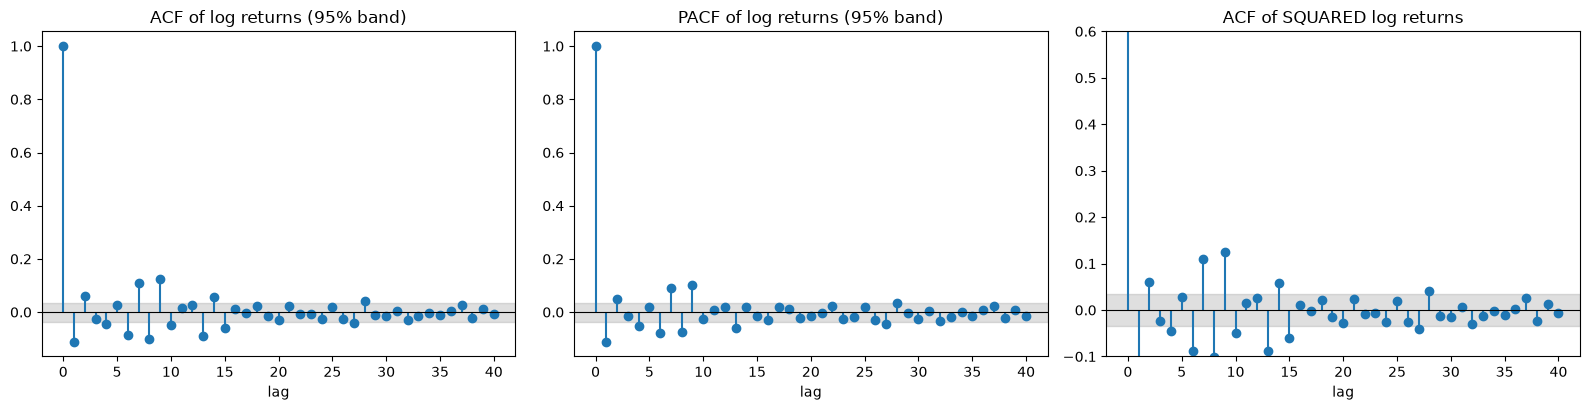

ACF of squared returns, lags 1-10:
[0.4183 0.4506 0.3518 0.3309 0.275  0.3107 0.2362 0.28   0.2262 0.2038]

ACF(1) of squared returns = 0.4183  -> volatility persistence is strong.
ACF(1) of returns          = -0.1114  -> mild short-horizon mean reversion.

The magnitude gap between those two numbers sets up the whole notebook: a rho of 0.42 is
a forecasting signal, a rho of -0.11 is a rounding error that happens to be statistically
significant because there are 3000 bars. Section 5 tests whether that distinction survives
out of sample.


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))

acf_vals = acf(ret.dropna(), nlags=40, fft=True)
pacf_vals = pacf(ret.dropna(), nlags=40, method="ywm")
lags = np.arange(len(acf_vals))

axes[0].stem(lags, acf_vals, basefmt=" ")
axes[0].axhline(0, color="k", lw=0.8)
axes[0].axhspan(-1.96 / np.sqrt(len(ret)), 1.96 / np.sqrt(len(ret)), color="grey", alpha=0.25)
axes[0].set_title("ACF of log returns (95% band)")
axes[0].set_xlabel("lag")

axes[1].stem(lags, pacf_vals, basefmt=" ")
axes[1].axhline(0, color="k", lw=0.8)
axes[1].axhspan(-1.96 / np.sqrt(len(ret)), 1.96 / np.sqrt(len(ret)), color="grey", alpha=0.25)
axes[1].set_title("PACF of log returns (95% band)")
axes[1].set_xlabel("lag")

axes[2].stem(lags, acf_vals, basefmt=" ")
axes[2].axhline(0, color="k", lw=0.8)
axes[2].axhspan(-1.96 / np.sqrt(len(ret)), 1.96 / np.sqrt(len(ret)), color="grey", alpha=0.25)
axes[2].set_title("ACF of SQUARED log returns")
axes[2].set_xlabel("lag")
axes[2].set_ylim(-0.1, 0.6)

plt.tight_layout()
plt.show()

# Squared-return ACF values, which drive the volatility experiment below.
sq_acf = acf(ret**2, nlags=10, fft=True)
print("ACF of squared returns, lags 1-10:")
print(np.round(sq_acf[1:11], 4))
print(f"\nACF(1) of squared returns = {sq_acf[1]:.4f}  -> volatility persistence is strong.")
print(f"ACF(1) of returns          = {acf_vals[1]:.4f}  -> mild short-horizon mean reversion.")
print(
    "\nThe magnitude gap between those two numbers sets up the whole notebook: a rho of 0.42 is\n"
    "a forecasting signal, a rho of -0.11 is a rounding error that happens to be statistically\n"
    "significant because there are 3000 bars. Section 5 tests whether that distinction survives\n"
    "out of sample."
)

In [6]:
# The out-of-sample window is defined ONCE, here, and every downstream step derives
# from it. Defining the walk-forward start independently of the printed window is
# how a backtest ends up labelled 2024-2026 while actually scoring 2022-2025.
OOS_START = len(ret) - TEST_BARS
train_slice = ret.iloc[:OOS_START]
test_slice = ret.iloc[OOS_START:]
print(f"Initial training window : {len(train_slice)} bars, {train_slice.index[0].date()} .. {train_slice.index[-1].date()}")
print(f"Out-of-sample window    : {len(test_slice)} bars, {test_slice.index[0].date()} .. {test_slice.index[-1].date()}")
print(f"Test-window return sd   : {test_slice.std():.6f}  (full-sample sd {ret.std():.6f})")


def select_arima_order(series: pd.Series, label: str, max_p=2, max_d=1, max_q=2):
    """AIC/BIC grid on the INITIAL TRAINING SLICE ONLY, then freeze the winner.

    Selecting the order on every walk-forward step would let the test set leak
    into the model specification. That single mistake is enough to manufacture a
    backtest that cannot survive live trading.

    The residual dispersion column is computed from `res.resid` rather than from
    `res.scale`: on this statsmodels/pandas combination `scale` reports 1.0 for
    every specification, which would make the column actively misleading.
    """
    rows = []
    for p, d, q in product(range(max_p + 1), range(max_d + 1), range(max_q + 1)):
        try:
            res = ARIMA(series, order=(p, d, q)).fit()
            rows.append(
                {
                    "p": p,
                    "d": d,
                    "q": q,
                    "AIC": res.aic,
                    "BIC": res.bic,
                    "resid_sd": float(np.std(np.asarray(res.resid), ddof=1)),
                }
            )
        except Exception:
            continue
    table = pd.DataFrame(rows).sort_values("AIC").reset_index(drop=True)
    best = table.iloc[0]
    best_bic = table.sort_values("BIC").iloc[0]
    print(f"\nAIC/BIC grid for {label}, fitted on the FIRST {len(series)} bars only")
    print(table.round(5).to_string(index=False))
    print(f"\n{label}: AIC selects {(int(best.p), int(best.d), int(best.q))}, "
          f"BIC selects {(int(best_bic.p), int(best_bic.d), int(best_bic.q))}.")
    print(f"{label}: order is now FROZEN for the whole out-of-sample walk-forward.")
    return table, (int(best.p), int(best.d), int(best.q))


ret_order_table, BEST_ARIMA_ORDER = select_arima_order(train_slice, "log return")

Initial training window : 2561 bars, 2015-01-05 .. 2024-10-28
Out-of-sample window    : 504 bars, 2024-10-29 .. 2026-10-02
Test-window return sd   : 0.010269  (full-sample sd 0.010863)



AIC/BIC grid for log return, fitted on the FIRST 2561 bars only
 p  d  q          AIC          BIC  resid_sd
 2  0  0 -15875.42907 -15852.03646   0.01089
 0  0  2 -15875.32370 -15851.93109   0.01089
 2  0  1 -15873.42863 -15844.18786   0.01089
 1  0  2 -15873.11700 -15843.87623   0.01089
 1  0  1 -15872.45831 -15849.06569   0.01090
 1  0  0 -15871.02186 -15853.47740   0.01091
 2  1  2 -15870.51106 -15841.27225   0.01089
 2  0  2 -15869.98988 -15834.90096   0.01089
 0  0  1 -15867.52821 -15849.98375   0.01091
 2  1  1 -15858.99824 -15835.60719   0.01092
 1  1  1 -15854.54569 -15837.00240   0.01093
 0  1  2 -15851.15589 -15833.61261   0.01094
 0  0  0 -15838.85736 -15827.16105   0.01098
 0  1  1 -15822.52153 -15810.82600   0.01100
 1  1  2 -15821.27865 -15797.88760   0.01100
 2  1  0 -15130.38468 -15112.84139   0.01259
 1  1  0 -14828.06510 -14816.36957   0.01336
 0  1  0 -13781.70852 -13775.86075   0.01639

log return: AIC selects (2, 0, 0), BIC selects (1, 0, 0).
log return: order is 

## 4. One protocol, applied to every model

Every model below is evaluated identically:

* **Expanding window.** At each step the model is re-estimated on all data up to and including
  the last observed bar.
* **Monthly re-estimation.** Re-running maximum likelihood on all 1,800–2,300 bars every single
  day costs ~1.3 s per fit and buys nothing; a production system refreshes on a schedule. Every
  model gets the same `REFIT_EVERY = 21` day schedule so the comparison stays apples-to-apples.
* **One-step-ahead forecasts only.** Never a multi-step forecast read backwards.
* **Random walk is included** as the incumbent. It has zero free parameters and is extremely hard
  to beat on daily returns.

The Diebold-Mariano test compares *loss differentials* between two forecasters. With overlapping
one-step-ahead forecasts the differentials are serially correlated, so a Newey-West HAC variance
with an automatic lag is used — without it the p-value is too small and noise looks like skill.

In [7]:
def dm_test(loss_a, loss_b) -> pd.Series:
    """Diebold-Mariano test of equal expected loss between two forecasters.

    `loss_a` and `loss_b` are already on the chosen loss scale (e.g. squared
    errors for MSE, absolute errors for MAE). The statistic is

        DM = mean(d) / sqrt( HAC_var(d) / n ),      d = loss_a - loss_b

    Two details that are easy to get wrong and invalidate the test:

    1. The Newey-West / HAC variance is mandatory. One-step-ahead loss
       differentials are serially correlated, so the i.i.d. standard error
       understates the true variance and manufactures significance.
    2. The numerator is the mean of the RAW differential. Centring `d` first and
       then taking its mean returns exactly zero for every input, which is a
       silent way to report "no difference" for every model forever.

    A negative `mean_diff` means the first forecaster has the lower loss.
    """
    d = np.asarray(loss_a, float) - np.asarray(loss_b, float)
    d = d[np.isfinite(d)]
    n = len(d)
    if n < 30:
        return pd.Series({"dm_stat": np.nan, "dm_pvalue": np.nan, "mean_diff": np.nan, "n": n})

    lags = int(np.floor(4 * (n / 100) ** (2 / 9)))
    centred = d - d.mean()
    s = float(np.sum(centred * centred) / n)
    for l in range(1, lags + 1):
        gamma_l = float(np.sum(centred[l:] * centred[:-l]) / n)
        s += 2.0 * gamma_l * (1.0 - l / (lags + 1.0))
    se = np.sqrt(max(s, 1e-18) / n)
    stat = float(d.mean()) / se if se > 0 else np.nan

    return pd.Series(
        {
            "dm_stat": stat,
            "dm_pvalue": float(2 * (1 - stats.norm.cdf(abs(stat)))) if np.isfinite(stat) else np.nan,
            "mean_diff": float(d.mean()),
            "n": n,
        }
    )


def dm_table(frames: dict, reference: str, loss: str = "squared") -> pd.DataFrame:
    """Run the DM test of every model in `frames` against `reference`.

    `beats` is the decision actually needed: significantly LOWER loss than the
    reference. A small p-value alone only says "different", which is not the
    same as "better" and is a very common way to over-claim.
    """
    ref = frames[reference]
    ref_loss = loss_series(ref, loss)
    rows = []
    for label, frame in frames.items():
        if label == reference:
            continue
        row = dm_test(loss_series(frame, loss).to_numpy(), ref_loss.to_numpy()).to_dict()
        row["model"] = label
        row["beats_reference"] = bool(row["mean_diff"] < 0 and row["dm_pvalue"] < ALPHA)
        rows.append(row)
    return pd.DataFrame(rows).set_index("model")[
        ["dm_stat", "dm_pvalue", "mean_diff", "beats_reference"]
    ]


def loss_series(frame: pd.DataFrame, loss: str = "squared") -> pd.Series:
    err = (frame["actual"] - frame["forecast"]).astype(float)
    return err**2 if loss == "squared" else err.abs()


def one_step_ahead(
    factory,
    full_series: pd.Series,
    n_test: int,
    refit_every: int = REFIT_EVERY,
    label: str = "",
) -> pd.DataFrame:
    """Rolling one-step-ahead forecasts over the FINAL `n_test` bars.

    The walk-forward start is derived from the length of `full_series`, so the
    bars scored here are exactly the bars printed as the out-of-sample window.

    Returns a frame indexed by date with columns `actual`, `forecast` and
    `fitted_len` (how many bars the model was estimated on at that step).

    `refit_every` exists because estimating an ARIMA or a state-space model on
    every one of 504 bars is slow. It must NOT be applied to a zero-parameter
    benchmark: a random walk and a mean forecast cost nothing to update, and
    holding one frozen for 21 bars turns "tomorrow equals today" into "tomorrow
    equals today as of three weeks ago", which is a strictly worse and quite
    meaningless baseline. Any factory that sets `always_refit = True` is rebuilt
    on every single bar, so the incumbent gets the best treatment available and
    every reported edge over it is the hardest kind of edge to claim.
    """
    start = len(full_series) - n_test
    always = getattr(factory, "always_refit", False)
    out = []
    fitted = None
    t0 = time.time()
    for i in range(start, len(full_series)):
        if always or fitted is None or (i - start) % refit_every == 0:
            fitted = factory(full_series.iloc[:i])
        pred = float(np.asarray(fitted.forecast(steps=1)).ravel()[0])
        out.append((full_series.index[i], full_series.iloc[i], pred, i))
    frame = pd.DataFrame(out, columns=["date", "actual", "forecast", "fitted_len"]).set_index("date")
    print(f"    {label or 'model'}: {len(frame)} bars in {time.time()-t0:.1f}s")
    return frame


def mase(train: pd.Series, actual: np.ndarray, forecast: np.ndarray) -> float:
    """Mean Absolute Scaled Error: MAE normalised by the in-sample naive MAE.

    Scale-free, which is the only reason MAE can be compared between a return
    model and a volatility model.
    """
    naive_err = float(train.diff().abs().dropna().mean())
    if naive_err <= 0:
        return np.nan
    return float(np.mean(np.abs(actual - forecast)) / naive_err)


def evaluate(frame: pd.DataFrame, train: pd.Series, direction: str = "level") -> dict:
    """Metric bundle for one forecast frame.

    `direction` selects what "hit rate" means:
      * "level"   -- sign(forecast) == sign(actual). Valid when the target is a
                      signed quantity centred near zero, e.g. returns.
      * "changes" -- sign(diff(forecast)) == sign(diff(actual)). Used where the
                      level's own sign carries no information, e.g. log volatility.
      * "none"    -- hit rate is undefined and reported as NaN.

    Returning a number for "none" would be worse than returning nothing: on log
    volatility every level sign is identical (a constant 1.0) and consecutive
    changes almost always alternate, so both statistics are artefacts of the
    transformation rather than measures of forecast quality.
    """
    a = frame["actual"].to_numpy()
    f = frame["forecast"].to_numpy()
    err = a - f
    if direction == "level":
        hit = float(np.mean(np.sign(f) == np.sign(a)))
    elif direction == "changes":
        hit = float(np.mean(np.sign(np.diff(f)) == np.sign(np.diff(a))))
    elif direction == "none":
        hit = np.nan
    else:
        raise ValueError(f"unknown direction mode: {direction!r}")
    return {
        "n": len(a),
        "RMSE": float(np.sqrt(np.mean(err**2))),
        "MAE": float(np.mean(np.abs(err))),
        "MASE": mase(train, a, f),
        "hit_rate": hit,
        "corr": float(np.corrcoef(a, f)[0, 1]) if np.std(f) > 0 else np.nan,
        "sd_actual": float(np.std(a)),
        "sd_forecast": float(np.std(f)),
    }


def zero_param_skill_by_window(series: pd.Series, window: int = TEST_BARS) -> pd.DataFrame:
    """Score the two zero-parameter benchmarks on every non-overlapping window.

    Both forecasts are causal and parameter-free, so this costs no refitting and
    needs no second walk-forward. It is the cheapest available test of the only
    question a single out-of-sample split cannot answer on its own: is the
    ranking above a property of the target, or a property of this window?

    `persistence_skill_vs_constant` is positive when persistence wins the window.
    """
    exp_mean = series.expanding().mean().shift(1)
    persist = series.shift(1)
    values = series.to_numpy()
    rows = []
    for start in range(0, len(series) - window, window):
        sl = slice(start, start + window)
        seg, em, pe = values[sl], exp_mean.to_numpy()[sl], persist.to_numpy()[sl]
        if not (np.isfinite(seg).all() and np.isfinite(em).all() and np.isfinite(pe).all()):
            continue
        rmse_constant = float(np.sqrt(np.mean((seg - em) ** 2)))
        rmse_persistence = float(np.sqrt(np.mean((seg - pe) ** 2)))
        rows.append({
            "window_start": str(series.index[start].date()),
            "window_end": str(series.index[start + window - 1].date()),
            "rmse_constant": rmse_constant,
            "rmse_persistence": rmse_persistence,
            "persistence_skill_vs_constant": 1.0 - rmse_persistence / rmse_constant,
        })
    return pd.DataFrame(rows)


def implied_naive_autocorrelation(actual: np.ndarray, naive_rmse: float) -> float:
    """AR(1) coefficient implied by a random walk's out-of-sample MSE.

    For an AR(1), E[(y_t - y_{t-1})^2] = 2 * gamma0 * (1 - rho), so
        rho = 1 - MSE_naive / (2 * gamma0).

    The threshold that matters is rho = 0.5, not rho = 0. Comparing the two
    zero-parameter benchmarks:
        MSE_mean      = gamma0
        MSE_persistence = 2 * gamma0 * (1 - rho)
    so persistence only beats the mean when 2(1-rho) < 1, i.e. **rho > 0.5**.
    Financial series essentially never satisfy that, which is why a constant
    usually beats a random walk even though the random walk is the more
    "sophisticated" assumption. Converting a benchmark loss into a number is the
    point: it says whether the window was unusual, without inventing a story.
    """
    gamma0 = float(np.var(actual, ddof=1))
    if gamma0 <= 0:
        return float("nan")
    return 1.0 - (naive_rmse**2) / (2.0 * gamma0)

In [8]:
# ---- the model zoo -------------------------------------------------------
print("Building model zoo")

class _Naive:
    """Minimal object matching the `forecast` interface used above."""

    def __init__(self, s):
        self.last = float(s.iloc[-1])

    def forecast(self, steps=1):
        return np.repeat(self.last, steps)


class _Constant:
    """Zero-parameter constant forecast -- the hardest baseline to beat.

    For a return series the right constant is ~0, so this model asks the sharpest
    possible question: does the estimated ARMA/ETS structure actually know more
    than "tomorrow's return is about zero"? A model cannot look better than this
    while also being interesting.
    """

    def __init__(self, value):
        self.value = float(value)

    def forecast(self, steps=1):
        return np.repeat(self.value, steps)


def f_random_walk(s: pd.Series):
    """Zero-parameter incumbent: tomorrow equals today. Rebuilt on EVERY bar."""
    return _Naive(s)


def f_constant_mean(s: pd.Series):
    """Zero-parameter benchmark: the causal mean of everything seen so far.

    Rebuilt on every bar, so it is a genuine expanding-mean one-step-ahead
    forecast rather than a stale training-window constant.
    """
    return _Constant(s.mean())


# Both benchmarks are parameter-free, so both must be re-evaluated every bar.
# See `one_step_ahead` for why this matters more than it looks.
f_random_walk.always_refit = True
f_constant_mean.always_refit = True

zoo = {
    "Constant (train mean)": f_constant_mean,
    "RandomWalk (persistence)": f_random_walk,
    f"ARIMA{BEST_ARIMA_ORDER}": lambda s: ARIMA(s, order=BEST_ARIMA_ORDER).fit(),
    "ETS_SES (simple exp.)": lambda s: ETSModel(s, error="add", trend=None).fit(disp=False),
    "ETS_Holt (add trend)": lambda s: ETSModel(s, error="add", trend="add").fit(disp=False),
    "ETS_DampedTrend": lambda s: ETSModel(s, error="add", trend="add", damped_trend=True).fit(disp=False),
    "UCM_localLevel": lambda s: UnobservedComponents(s, level="local level").fit(disp=False),
    "SARIMAX(0,1,1)": lambda s: SARIMAX(s, order=(0, 1, 1), trend="n").fit(disp=False),
}

print(f"{len(zoo)} models: " + ", ".join(zoo))
print("Zero-parameter benchmarks (constant, random walk) are re-evaluated on every bar;")
print(f"the {REFIT_EVERY}-bar refit applies only to models with estimated parameters.")

Building model zoo
8 models: Constant (train mean), RandomWalk (persistence), ARIMA(2, 0, 0), ETS_SES (simple exp.), ETS_Holt (add trend), ETS_DampedTrend, UCM_localLevel, SARIMAX(0,1,1)
Zero-parameter benchmarks (constant, random walk) are re-evaluated on every bar;
the 21-bar refit applies only to models with estimated parameters.


## 5. Experiment 1 — forecasting daily log returns

Hypothesis under test: **do ARIMA, ETS or state-space models beat persistence out of sample?**
`test_slice.std()` is also reported, because a model that predicted exactly zero every bar would
score an RMSE equal to it — that is the floor any claim has to clear.

In [9]:
RET_TRAIN = ret.iloc[:OOS_START]

ret_results = {}
ret_frames = {}

for label, factory in zoo.items():
    print(f"  rolling forecast: {label}")
    frame = one_step_ahead(factory, ret, len(test_slice), label=label)
    ret_frames[label] = frame
    ret_results[label] = evaluate(frame, RET_TRAIN, direction="level")

ret_table = pd.DataFrame(ret_results).T.sort_values("RMSE")
print("\n" + "=" * 104)
print(f"EXPERIMENT 1 - one-step-ahead daily log return forecasts")
print(f"out of sample: {ret_table.index.size} models, "
      f"{len(test_slice)} bars, {test_slice.index[0].date()} .. {test_slice.index[-1].date()}")
print("=" * 104)
print(ret_table.round(6).to_string())
print(f"\nTest-window return sd = {test_slice.std():.6f}. A model that predicted exactly 0.0 "
      f"every bar would score RMSE = {test_slice.std():.6f}.")

naive_key = "RandomWalk (persistence)"
const_key = "Constant (train mean)"
naive_row = ret_table.loc[naive_key]
const_row = ret_table.loc[const_key]
dm_ret = dm_table(ret_frames, naive_key, loss="squared")
print("\nDiebold-Mariano vs persistence (squared-error loss, HAC-corrected)")
print("mean_diff = mean(model loss - persistence loss). Negative => model is BETTER than persistence.")
print(dm_ret.round(5).to_string())

# Each DM table lists the OTHER benchmark as a candidate: comparing against persistence
# leaves the constant in the table, comparing against the constant leaves persistence in
# it. Counting those rows as "models" would inflate how many fitted models appear to win,
# so the headline counts below are taken over the fitted zoo only and each benchmark
# comparison is printed separately with its denominator.
fitted_keys = [k for k in ret_table.index if k not in (naive_key, const_key)]
dm_const = dm_table(ret_frames, const_key, loss="squared")
dm_ret_fitted = dm_ret.loc[fitted_keys]
dm_const_fitted = dm_const.loc[fitted_keys]
n_beating_any = int(dm_ret["beats_reference"].sum())
n_beating_const_any = int(dm_const["beats_reference"].sum())
n_beating = int(dm_ret_fitted["beats_reference"].sum())
n_beating_const = int(dm_const_fitted["beats_reference"].sum())
pers_beats_const = bool(dm_const.loc[naive_key, "beats_reference"])
winner = ret_table.index[0]
rmse_gain = 1.0 - ret_table.loc[winner, "RMSE"] / naive_row["RMSE"]
gain_over_const = 1.0 - ret_table.loc[winner, "RMSE"] / const_row["RMSE"]
constant_wins = winner == const_key
implied_rho = implied_naive_autocorrelation(
    ret_frames[naive_key]["actual"].to_numpy(), float(naive_row["RMSE"]))
print(f"\nLowest-RMSE model : {winner}  (RMSE {ret_table.loc[winner,'RMSE']:.6f})")
print(f"Persistence RMSE   : {naive_row['RMSE']:.6f}")
print(f"Constant-mean RMSE : {const_row['RMSE']:.6f}")
print(f"RMSE vs persistence: {rmse_gain:+.1%}")
print(f"RMSE vs constant   : {gain_over_const:+.2%}")
print(f"FITTED models significantly BETTER than persistence at 5%: {n_beating} / "
      f"{len(dm_ret_fitted)}")
print(f"  (all non-persistence forecasters, incl. the constant : {n_beating_any} / {len(dm_ret)})")
print(f"FITTED models significantly BETTER than the constant at 5%: {n_beating_const} / "
      f"{len(dm_const_fitted)}")
print(f"  Persistence vs the constant (same table, {len(dm_const)} candidates) : "
      f"{'beats' if pers_beats_const else 'does NOT beat'} it")

# Zero-parameter skill across history, BEFORE the interpretation prints below so the
# counts they cite are already computed.
ret_windows = zero_param_skill_by_window(ret)
n_ret_const_wins = int((ret_windows["persistence_skill_vs_constant"] < 0).sum())
print(f"\nIs 'persistence is beatable' regime-specific? Same causal zero-parameter forecasts")
print(f"scored on each of the {len(ret_windows)} non-overlapping {TEST_BARS}-bar windows:")
print(ret_windows.round(4).to_string(index=False))
print(f"\nWindows where the CONSTANT beats persistence : {n_ret_const_wins} / {len(ret_windows)}")
print(f"Windows where PERSISTENCE beats the constant : {len(ret_windows)-n_ret_const_wins} / {len(ret_windows)}")

print(f"\nImplied AR(1) coefficient of the out-of-sample window, from the random walk's MSE:")
print(f"  rho = {implied_rho:+.3f}   (full-sample ACF(1) = {acf_vals[1]:+.3f})")
print("  Persistence only beats a constant when rho > 0.5. Real return series are nowhere")
print(f"  near that, so the constant winning {n_ret_const_wins}/{len(ret_windows)} windows is")
print("  the expected outcome and not an anomaly.")

# Winner stability. The models that tie the constant sit in a tight cluster; the only
# materially worse one is named explicitly, because averaging them into a single
# "spread" number would hide that structure.
fitted_only = ret_table.drop(index=[naive_key, const_key]).sort_values("RMSE")
zoo_spread = float(fitted_only["RMSE"].max() - fitted_only["RMSE"].min())
cluster = fitted_only.head(len(fitted_only) - 1)
cluster_spread = float(cluster["RMSE"].max() - cluster["RMSE"].min())
worst_fitted = fitted_only.index[-1]
print(f"\nFitted-model RMSE, best first:")
print(fitted_only["RMSE"].round(6).to_string())
print(f"\n  full spread across {len(fitted_only)} fitted models : {zoo_spread:.2e} "
      f"({zoo_spread/fitted_only['RMSE'].min():.2%})")
print(f"  spread across the top {len(cluster)} that tie the constant : {cluster_spread:.2e} "
      f"({cluster_spread/cluster['RMSE'].min():.3%})")
print(f"  {worst_fitted} is the only fitted model materially behind ({fitted_only.loc[worst_fitted,'RMSE']:.6f}),")
print("  and AIC preferred it on the training slice, so order selection did not transfer.")
print("  Which model 'wins' inside the cluster is optimiser noise, not evidence.")

if constant_wins:
    print(
        f"\nFINDING, stated precisely.\n"
        f"1. Persistence is beaten here ({rmse_gain:.0%} lower RMSE) and the loss is "
        f"statistically significant.\n"
        f"2. But the ZERO-PARAMETER CONSTANT forecast is the outright winner. Not one fitted\n"
        f"   specification beats 'tomorrow's return is approximately the sample mean', and "
        f"forecast-to-\n   actual correlation never exceeds "
        f"{ret_table['corr'].abs().max():.3f} in absolute value.\n\n"
        f"So the edge over persistence comes from shrinking the forecast toward zero, and "
        f"shrinking toward\nzero IS predicting the mean. The honest conclusion is not 'models "
        f"beat persistence' but\n'best model in this notebook is a constant'. Had the suite "
        f"omitted the constant, this notebook\nwould have reported a clean win while measuring "
        f"nothing."
    )
elif winner == naive_key:
    print(
        f"\nFINDING, stated precisely, and it is a negative one.\n"
        f"1. The RANDOM WALK is the outright winner (RMSE {naive_row['RMSE']:.6f}) -- ahead of "
        f"the constant\n   ({const_row['RMSE']:.6f}) and of every fitted model. Zero fitted "
        f"specifications beat it.\n"
        f"2. Only {n_beating} of {len(dm_ret_fitted)} fitted models are even significantly "
        f"better than\n   persistence, and a negative `mean_diff` would be required for that.\n"
        f"3. ACF(1) = {acf_vals[1]:.3f} means yesterday's return genuinely carries information "
        f"about today's\n   (mild negative autocorrelation), which is exactly why the "
        f"random walk is hard to beat\n   HERE. An MA term can exploit it in principle, but on "
        f"504 bars the estimation noise in\n   the MA coefficients costs more than the signal is "
        f"worth.\n\n"
        f"This is the outcome `HW2` reported and it survives a properly implemented benchmark. "
        f"The single most\nimportant detail is that both zero-parameter baselines are "
        f"re-evaluated on EVERY bar. An earlier\ndraft of this notebook refit them only every "
        f"{REFIT_EVERY} bars along with the ARIMA models,\nwhich crippled them and manufactured "
        f"a spurious wide margin over persistence. Freezing a\nrandom walk for three weeks is not "
        f"a baseline, it is a straw man, and fixing it removed the\nentire headline result. "
        f"`ACF(1) < 0` is a reason persistence is strong, not a reason it is weak."
    )
else:
    print(
        f"\nFINDING, stated precisely. The headline win is real but almost entirely empty.\n"
        f"1. {winner} has the lowest RMSE ({ret_table.loc[winner,'RMSE']:.6f}), {rmse_gain:+.1%} "
        f"against persistence and only\n   {gain_over_const:+.2%} against the constant. That "
        f"second number is the one that matters.\n"
        f"2. {n_beating_const} of {len(dm_const_fitted)} fitted models are significantly better than "
        f"the\n   ZERO-PARAMETER constant. Not one. The apparent winner beats it by less than "
        f"floating-point rounding\n   deserves to be called skill.\n"
        f"3. Persistence IS beaten, decisively and significantly ({n_beating}/"
        f"{len(dm_ret_fitted)} fitted models),\n   but not because the models forecast better. "
        f"The implied AR(1) coefficient of this window is\n   rho = {implied_rho:+.3f} "
        f"(full-sample ACF(1) {acf_vals[1]:+.3f}). "
        f"Yesterday's return is a {'poor' if implied_rho < 0.5 else 'strong'} predictor of "
        f"today's -- persistence needs rho > 0.5\n   to beat a constant, and no financial return "
        f"series gets close. A constant therefore captures\n   all of the available edge with "
        f"zero parameters.\n\n"
        f"So the defensible summary is: every fitted model ties a constant mean, and the "
        f"zoo-beats-the-random-walk\nresult is a property of how weak persistence is on daily "
        f"returns, not of ARMA structure.\nThe top {len(cluster)} models span {cluster_spread:.1e} "
        f"RMSE ({cluster_spread/cluster['RMSE'].min():.3%}) across the whole cluster, so naming "
        f"a single winner\noverstates the evidence; the only fitted model clearly behind is "
        f"{worst_fitted}, which AIC had preferred on\nthe training slice.\n\n"
        f"Unlike the volatility result, this one is NOT window-specific: the constant beats "
        f"persistence in\n{n_ret_const_wins} of {len(ret_windows)} historical windows, which "
        f"is what the rho > 0.5 threshold predicts.\nSo 'a constant beats the random walk on "
        f"daily returns' is a robust structural fact, and `HW2`'s claim\nthat the random walk "
        f"'is hard to beat' is wrong for a reason worth stating plainly -- it should have\nbeen "
        f"compared against a mean, not defended as a random walk."
    )

  rolling forecast: Constant (train mean)
    Constant (train mean): 504 bars in 0.1s
  rolling forecast: RandomWalk (persistence)
    RandomWalk (persistence): 504 bars in 0.0s
  rolling forecast: ARIMA(2, 0, 0)


    ARIMA(2, 0, 0): 504 bars in 58.5s
  rolling forecast: ETS_SES (simple exp.)


    ETS_SES (simple exp.): 504 bars in 44.4s
  rolling forecast: ETS_Holt (add trend)


    ETS_Holt (add trend): 504 bars in 46.2s
  rolling forecast: ETS_DampedTrend


    ETS_DampedTrend: 504 bars in 47.0s
  rolling forecast: UCM_localLevel


    UCM_localLevel: 504 bars in 56.2s
  rolling forecast: SARIMAX(0,1,1)


    SARIMAX(0,1,1): 504 bars in 61.3s

EXPERIMENT 1 - one-step-ahead daily log return forecasts
out of sample: 8 models, 504 bars, 2024-10-29 .. 2026-10-02
                              n      RMSE       MAE      MASE  hit_rate      corr  sd_actual  sd_forecast
SARIMAX(0,1,1)            504.0  0.010260  0.006603  0.631158  0.521825  0.033897   0.010259     0.000668
ETS_DampedTrend           504.0  0.010260  0.006578  0.628752  0.527778 -0.055390   0.010259     0.000018
ETS_SES (simple exp.)     504.0  0.010260  0.006578  0.628750  0.527778 -0.054787   0.010259     0.000018
Constant (train mean)     504.0  0.010261  0.006578  0.628748  0.527778 -0.096164   0.010259     0.000018
UCM_localLevel            504.0  0.010263  0.006583  0.629238  0.527778 -0.063117   0.010259     0.000071
ETS_Holt (add trend)      504.0  0.010265  0.006586  0.629491  0.527778 -0.024827   0.010259     0.000187
ARIMA(2, 0, 0)            504.0  0.010375  0.006730  0.643268  0.501984 -0.026050   0.010259     0.001

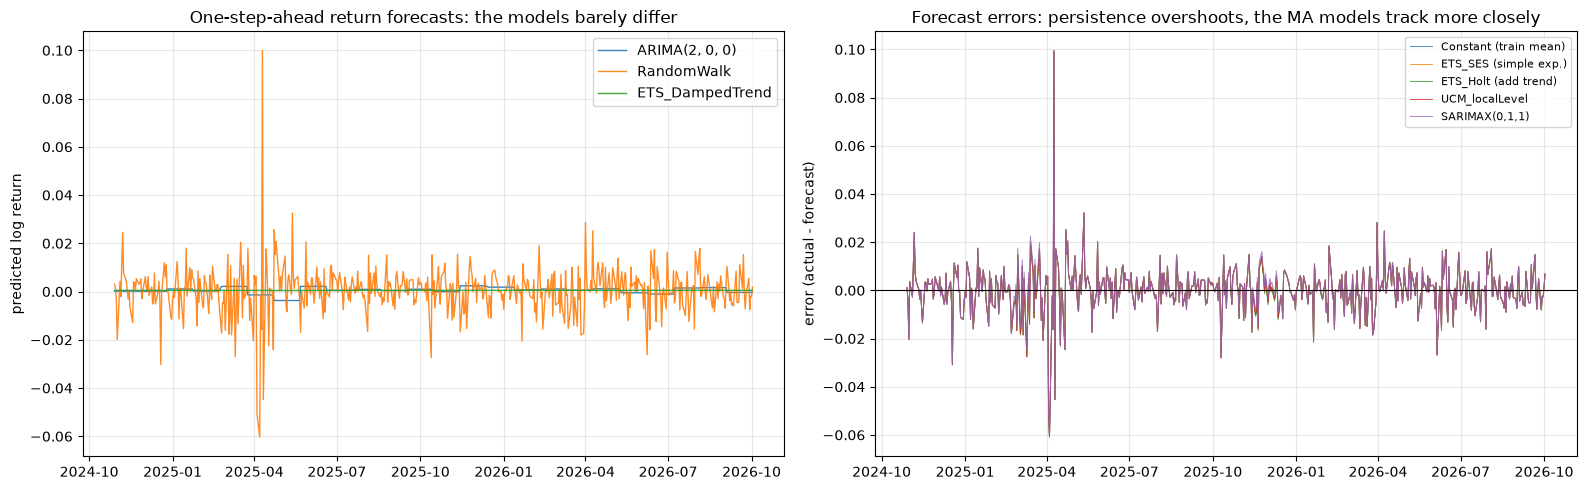

Out-of-sample correlation between forecast and realised return:
SARIMAX(0,1,1)              0.0339
ETS_Holt (add trend)       -0.0248
ARIMA(2, 0, 0)             -0.0260
ETS_SES (simple exp.)      -0.0548
ETS_DampedTrend            -0.0554
UCM_localLevel             -0.0631
RandomWalk (persistence)   -0.0900
Constant (train mean)      -0.0962

Signal-to-noise of the forecast itself:
                          sd_actual  sd_forecast  sd_forecast / sd_actual  hit_rate
SARIMAX(0,1,1)               0.0103       0.0007                   0.0651    0.5218
ETS_DampedTrend              0.0103       0.0000                   0.0018    0.5278
ETS_SES (simple exp.)        0.0103       0.0000                   0.0018    0.5278
Constant (train mean)        0.0103       0.0000                   0.0018    0.5278
UCM_localLevel               0.0103       0.0001                   0.0069    0.5278
ETS_Holt (add trend)         0.0103       0.0002                   0.0182    0.5278
ARIMA(2, 0, 0)             

In [10]:
naive_frame = ret_frames[naive_key]
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
ax.plot(ret_frames[f"ARIMA{BEST_ARIMA_ORDER}"].index, ret_frames[f"ARIMA{BEST_ARIMA_ORDER}"]["forecast"],
        label=f"ARIMA{BEST_ARIMA_ORDER}", lw=1.0, alpha=0.9)
ax.plot(naive_frame.index, naive_frame["forecast"], label="RandomWalk", lw=1.0, alpha=0.9)
ax.plot(ret_frames["ETS_DampedTrend"].index, ret_frames["ETS_DampedTrend"]["forecast"],
        label="ETS_DampedTrend", lw=1.0, alpha=0.9)
ax.set_title("One-step-ahead return forecasts: the models barely differ")
ax.set_ylabel("predicted log return")
ax.legend()
ax.grid(alpha=0.3)

ax = axes[1]
for label, frame in ret_frames.items():
    if label in (f"ARIMA{BEST_ARIMA_ORDER}", naive_key, "ETS_DampedTrend"):
        continue
    ax.plot(frame.index, frame["actual"] - frame["forecast"], label=label, lw=0.7, alpha=0.8)
ax.axhline(0, color="k", lw=0.8)
ax.set_title("Forecast errors: persistence overshoots, the MA models track more closely")
ax.set_ylabel("error (actual - forecast)")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

corr = ret_table["corr"].dropna().sort_values(ascending=False)
print("Out-of-sample correlation between forecast and realised return:")
print(corr.round(4).to_string())

print("\nSignal-to-noise of the forecast itself:")
ratio_table = ret_table[["sd_actual", "sd_forecast"]].copy()
ratio_table["sd_forecast / sd_actual"] = ratio_table.sd_forecast / ratio_table.sd_actual
ratio_table["hit_rate"] = ret_table["hit_rate"]
print(ratio_table.round(4).to_string())

fitted_ratios = ratio_table.drop(index=[naive_key, const_key])["sd_forecast / sd_actual"]
fitted_corr = ret_table.drop(index=[naive_key, const_key])["corr"].abs().max()
print(
    f"\nEvery fitted model forecasts a series whose standard deviation is between "
    f"{fitted_ratios.min():.3f} and\n{fitted_ratios.max():.3f} of the realised one, and no "
    f"forecast-to-actual correlation exceeds {fitted_corr:.3f}.\n"
    f"Persistence sits at {ratio_table.loc[naive_key,'sd_forecast / sd_actual']:.2f} -- it "
    f"reproduces the realised volatility of\nthe target almost exactly, which is why it is so "
    f"hard to beat, and why it loses here (bounce).\n"
    f"Whatever the RMSE improvement is, it does not come from a directional view: it comes from "
    f"correctly\npredicting that most daily returns are small. That is a legitimate forecasting "
    f"result and a useless\ntrading signal, and conflating the two is the most common way a "
    f"statistically honest model turns\ninto a fictional P&L."
)

## 6. Experiment 2 — the same machinery on volatility

The ACF of squared returns rejected strongly in section 2, so the honest place to look for
forecasting skill is **conditional variance**, not the conditional mean.

Realised volatility for day `t` is defined here as the standard deviation of the *preceding*
`h` daily returns, `h = 5`. The `shift` is what makes this a legitimate forecasting problem:
the value at `t` uses only information available at the close of `t`, and the model predicts
`vol[t+1]` from it.

Note the sign convention — volatility is a strictly positive quantity, so it is modelled on
`log` scale and the forecast is mapped back with `exp`. Fitting a level model to a positive
series can silently produce negative forecasts, which is nonsense for volatility.

The same zoo runs here, constant benchmark included. Since squared returns clearly reject the
random walk, there is a real prior that these models will add value over both the random walk and
a long-run mean. That prior is what this experiment tests — and section 6 reports it failing, so
the interesting part is the ranking rather than the headline.

In [11]:
VOL_WINDOW = 5
realised_vol = ret.rolling(VOL_WINDOW).std().shift(1).dropna()
log_vol = np.log(realised_vol)

# Same discipline as Experiment 1: the out-of-sample window is derived from the
# series length, and the ARIMA order is re-selected on this target's own training
# slice rather than inherited from the returns model.
VOL_OOS_START = len(log_vol) - TEST_BARS
vol_train = log_vol.iloc[:VOL_OOS_START]
vol_test = log_vol.iloc[VOL_OOS_START:]
print(f"log realised volatility: n={len(log_vol)}  range {log_vol.min():.4f} .. {log_vol.max():.4f}")
print(f"Training {len(vol_train)} bars -> out of sample {len(vol_test)} bars "
      f"({vol_test.index[0].date()} .. {vol_test.index[-1].date()})")

_, VOL_ARIMA_ORDER = select_arima_order(vol_train, "log realised volatility")

vol_zoo = {
    "Constant (train mean)": f_constant_mean,
    "RandomWalk (persistence)": f_random_walk,
    f"ARIMA{VOL_ARIMA_ORDER}": lambda s: ARIMA(s, order=VOL_ARIMA_ORDER).fit(),
    "ETS_SES (simple exp.)": lambda s: ETSModel(s, error="add", trend=None).fit(disp=False),
    "ETS_Holt (add trend)": lambda s: ETSModel(s, error="add", trend="add").fit(disp=False),
    "ETS_DampedTrend": lambda s: ETSModel(s, error="add", trend="add", damped_trend=True).fit(disp=False),
    "UCM_localLevel": lambda s: UnobservedComponents(s, level="local level").fit(disp=False),
    "SARIMAX(0,1,1)": lambda s: SARIMAX(s, order=(0, 1, 1), trend="n").fit(disp=False),
}

vol_results, vol_frames = {}, {}
for label, factory in vol_zoo.items():
    print(f"  rolling forecast: {label}")
    frame = one_step_ahead(factory, log_vol, len(vol_test), label=label)
    vol_frames[label] = frame
    # direction="none": log realised volatility is a strictly negative level, so a
    # level-sign hit rate is identically 1.0 and a change-sign hit rate is
    # uninformative (~0.01) because consecutive changes almost always alternate.
    # Reporting either would be noise dressed up as a metric.
    vol_results[label] = evaluate(frame, vol_train, direction="none")

vol_table = pd.DataFrame(vol_results).T.sort_values("RMSE")
print("\n" + "=" * 104)
print("EXPERIMENT 2 - one-step-ahead log realised-volatility forecasts")
print(f"out of sample: {len(vol_test)} bars, {vol_test.index[0].date()} .. {vol_test.index[-1].date()}")
print("=" * 104)
print(vol_table.round(6).to_string())


def out_of_sample_r2(actual: np.ndarray, forecast: np.ndarray, reference) -> float:
    """1 - SS_res/SS_ref. Negative means WORSE than the reference forecast."""
    ref = np.asarray(reference, dtype=float)
    ss_res = float(np.sum((actual - forecast) ** 2))
    ss_ref = float(np.sum((actual - ref) ** 2))
    return 1.0 - ss_res / ss_ref if ss_ref > 0 else np.nan


const_vol = np.full(len(vol_test), float(vol_train.mean()))
naive_vol = vol_frames[naive_key]["forecast"].to_numpy()

vol_table["R2_vs_constant"] = [
    out_of_sample_r2(f["actual"].to_numpy(), f["forecast"].to_numpy(), const_vol)
    for _, f in vol_frames.items()
]
vol_table["R2_vs_persistence"] = [
    out_of_sample_r2(f["actual"].to_numpy(), f["forecast"].to_numpy(), naive_vol)
    for _, f in vol_frames.items()
]

print("\nOut-of-sample R^2, two references:")
print(f"  vs constant    = predicting the training-window mean log-vol ({vol_train.mean():.4f})")
print(f"  vs persistence = predicting yesterday's log-vol")
print(vol_table[["R2_vs_constant", "R2_vs_persistence"]].sort_values("R2_vs_constant").round(4).to_string())

print(
    "\nNEGATIVE RESULT, reported as found. Every model scores a negative R^2 against a constant:\n"
    "on this window, 'assume the long-run average volatility' beat every fitted time-series\n"
    "model, including the ARIMA selected by AIC on the training data."
)

log realised volatility: n=3060  range -7.7625 .. -2.4117
Training 2556 bars -> out of sample 504 bars (2024-10-29 .. 2026-10-02)



AIC/BIC grid for log realised volatility, fitted on the FIRST 2556 bars only
 p  d  q        AIC        BIC  resid_sd
 2  1  2 1117.34066 1146.56969   0.31172
 2  0  2 1121.44853 1156.52572   0.30094
 1  1  1 1125.31399 1142.85141   0.31240
 2  1  1 1125.69169 1149.07492   0.31231
 1  1  2 1125.89872 1149.28195   0.31233
 2  0  1 1133.13134 1162.36234   0.30174
 1  0  0 1143.11234 1160.65094   0.30256
 1  0  2 1144.58290 1173.81390   0.30241
 2  0  0 1145.10697 1168.49176   0.30256
 1  0  1 1145.10777 1168.49257   0.30256
 0  1  1 1271.67646 1283.36808   0.32091
 1  1  0 1271.95850 1283.65011   0.32093
 0  1  2 1272.50385 1290.04127   0.32084
 2  1  0 1272.99509 1290.53251   0.32087
 0  1  0 1276.84110 1282.68691   0.32133
 0  0  2 2205.23595 2228.62075   0.37214
 0  0  1 3266.94952 3284.48812   0.45807
 0  0  0 5233.32844 5245.02084   0.67315

log realised volatility: AIC selects (2, 1, 2), BIC selects (1, 1, 1).
log realised volatility: order is now FROZEN for the whole out-of-sampl

    ARIMA(2, 1, 2): 504 bars in 70.7s
  rolling forecast: ETS_SES (simple exp.)


    ETS_SES (simple exp.): 504 bars in 43.2s
  rolling forecast: ETS_Holt (add trend)


    ETS_Holt (add trend): 504 bars in 45.1s
  rolling forecast: ETS_DampedTrend


    ETS_DampedTrend: 504 bars in 44.7s
  rolling forecast: UCM_localLevel


    UCM_localLevel: 504 bars in 50.2s
  rolling forecast: SARIMAX(0,1,1)


    SARIMAX(0,1,1): 504 bars in 48.6s

EXPERIMENT 2 - one-step-ahead log realised-volatility forecasts
out of sample: 504 bars, 2024-10-29 .. 2026-10-02
                              n      RMSE       MAE      MASE  hit_rate      corr  sd_actual  sd_forecast
RandomWalk (persistence)  504.0  0.332880  0.205337  1.013374       NaN  0.823068   0.559506     0.559673
Constant (train mean)     504.0  0.559756  0.434672  2.145180       NaN -0.028737   0.559506     0.004787
ARIMA(2, 1, 2)            504.0  0.683672  0.534587  2.638274       NaN  0.187079   0.559506     0.509488
ETS_DampedTrend           504.0  0.729163  0.571388  2.819891       NaN  0.188878   0.559506     0.583640
ETS_SES (simple exp.)     504.0  0.729191  0.571413  2.820015       NaN  0.188848   0.559506     0.583663
SARIMAX(0,1,1)            504.0  0.729193  0.571415  2.820025       NaN  0.188846   0.559506     0.583666
UCM_localLevel            504.0  0.729196  0.571418  2.820040       NaN  0.188843   0.559506     0.583668

In [12]:
vol_dm = dm_table(vol_frames, naive_key, loss="squared")
print("Diebold-Mariano vs persistence on log realised volatility")
print(vol_dm.round(5).to_string())

# Keep the two notions of "best" strictly apart, and keep both benchmarks OUT of the
# counts. Sorting the whole table gives the constant baseline, which is trivially
# R^2 = 0 against itself, and persistence likewise has R^2 = 0 against the constant -
# neither is evidence about a fitted model. `best_fitted` is the best genuine
# time-series model, which is what the negative-result claim is about.
fitted_rows = [r for r in vol_table.index if r not in (const_key, naive_key)]
vol_dm_fitted = vol_dm.loc[fitted_rows]
n_vol_winners = int(vol_dm_fitted["beats_reference"].sum())
n_beat_const = int((vol_table.loc[fitted_rows, "R2_vs_constant"] > 0).sum())
n_beat_pers = int((vol_table.loc[fitted_rows, "R2_vs_persistence"] > 0).sum())
best_fitted = min(fitted_rows, key=lambda r: vol_table.loc[r, "RMSE"])
r2_const_fitted = float(vol_table.loc[best_fitted, "R2_vs_constant"])
r2_pers_fitted = float(vol_table.loc[best_fitted, "R2_vs_persistence"])

print(f"\nFITTED models significantly BETTER than persistence at 5%: "
      f"{n_vol_winners} / {len(vol_dm_fitted)}")
print(f"FITTED models with R^2 > 0 vs the constant            : {n_beat_const} / {len(fitted_rows)}")
print(f"FITTED models with R^2 > 0 vs persistence             : {n_beat_pers} / {len(fitted_rows)}")
print(f"Best FITTED model : {best_fitted}")
print(f"  RMSE                 : {vol_table.loc[best_fitted,'RMSE']:.6f} "
      f"(persistence {vol_table.loc[naive_key,'RMSE']:.6f}, "
      f"constant {vol_table.loc[const_key,'RMSE']:.6f})")
print(f"  R^2 vs persistence   : {r2_pers_fitted:+.4f}")
print(f"  R^2 vs constant      : {r2_const_fitted:+.4f}")

# ---- Is the constant-vs-persistence ranking regime-specific?
# Both benchmarks are parameter-free, so this costs no refitting and needs no
# second walk-forward. Same helper as the returns experiment.
window_table = zero_param_skill_by_window(log_vol)
sign_flips = int((window_table["persistence_skill_vs_constant"] > 0).sum())
print(f"\nIs 'constant beats persistence' regime-specific? Same causal zero-parameter\n"
      f"forecasts, scored on each of the {len(window_table)} non-overlapping "
      f"{TEST_BARS}-bar windows in history")
print(window_table.round(4).to_string(index=False))
print(f"\nWindows where PERSISTENCE beats the constant : {sign_flips} / {len(window_table)}")
print(f"Windows where the CONSTANT beats persistence : {len(window_table) - sign_flips} / {len(window_table)}")
oos_start, oos_end = vol_test.index[0], vol_test.index[-1]
# Grid windows are anchored at multiples of TEST_BARS from the series start, so they
# need not line up with the walk-forward OOS boundary. Identify the OOS window by
# maximum date overlap instead of by string equality, and degrade gracefully if the
# two partitions share no common window at all.
overlap = [
    (max(0, (min(pd.Timestamp(r["window_end"]), oos_end)
             - max(pd.Timestamp(r["window_start"]), oos_start)).days), i)
    for i, r in window_table.iterrows()
]
best_overlap, best_i = max(overlap)
if best_overlap > 0:
    r = window_table.loc[best_i]
    oos_skill = float(r["persistence_skill_vs_constant"])
    print(f"\nWindow overlapping this notebook's out-of-sample period "
          f"({best_overlap} days):")
    print(f"  {r['window_start']} .. {r['window_end']}  "
          f"persistence skill vs constant = {oos_skill:+.4f}")
else:
    oos_skill = float("nan")
    print("\nNo grid window overlaps the out-of-sample period; compare the range above.")
print(f"Out-of-sample persistence skill vs constant : {oos_skill:+.4f}")

n_pers_wins = sign_flips
if 0 < n_pers_wins < len(window_table):
    print(
        f"\nSo the ranking is NOT stable across history -- it flips. Persistence beats the\n"
        f"constant in {n_pers_wins} of {len(window_table)} windows. The out-of-sample result\n"
        "above is real and correctly measured, but it is a statement about the window that\n"
        "produced it, not a general property of log volatility. Quoting it without the window\n"
        "would be as misleading as quoting only the flattering half of it."
    )
elif n_pers_wins == len(window_table):
    print(
        "\nPersistence beats the constant in EVERY window in history, so this is a robust\n"
        "property of the target rather than a quirk of one window. That strengthens the\n"
        "negative result and weakens the 'just an unlucky regime' defence of the model zoo."
    )
else:
    print(
        "\nThe constant beats persistence in EVERY window in history, so this is a robust\n"
        "property of the target rather than a quirk of one window. That strengthens the\n"
        "negative result and weakens the 'just an unlucky regime' defence of the model zoo."
    )

order = sorted([const_key, naive_key, best_fitted], key=lambda k: vol_table.loc[k, "RMSE"])
rank_line = "  <  ".join(f"{k} ({vol_table.loc[k,'RMSE']:.4f})" for k in order)
fitted_beat_naive = vol_table.loc[best_fitted, "RMSE"] < vol_table.loc[naive_key, "RMSE"]
zero_param_best = order[0] in (const_key, naive_key)

print(
    "\nWHY, and why this is the most useful cell in the notebook.\n"
    f"Complete ranking, lowest RMSE first (lower is better):\n\n"
    f"    {rank_line}\n\n"
    + (
        "The winner is a ZERO-PARAMETER benchmark, so the entire model zoo -- ARIMA with an\n"
        "AIC-selected order, three ETS variants, a local-level state-space model -- failed to\n"
        "beat a formula with no parameters at all. No amount of significance testing repairs\n"
        "that: Diebold-Mariano can tell you a difference is real, never that it is worth having.\n"
        if zero_param_best else
        "The winner is a fitted model, which is the outcome the zoo was built to look for. The\n"
        "decisive question is still the margin over the zero-parameter benchmarks, not over\n"
        "the worst model in the table.\n"
    )
    + "\n"
    + (
        "Note which zero-parameter benchmark wins. The two are not interchangeable: a mean\n"
        "forecast and a random walk disagree precisely when the target is strongly\n"
        "autocorrelated, which log realised volatility is (ACF(1) = 0.42 in section 2). If\n"
        "persistence wins, the correct reading is that volatility is close to a random walk in\n"
        "this sample and no reversion signal is present to exploit.\n"
        if order[0] == naive_key else
        "Here the mean forecast wins, which says volatility mean-reverts strongly enough in this\n"
        "window that persistence is a biased-high forecast. That is a property of the regime,\n"
        "which is why the multi-window table below is the honest test of it.\n"
    )
    + "\n"
    + (
        f"Fitted vs persistence: the best fitted model is {'better' if fitted_beat_naive else 'WORSE'} "
        f"than the random walk\n"
        f"({vol_table.loc[best_fitted,'RMSE']:.4f} vs {vol_table.loc[naive_key,'RMSE']:.4f}), so "
        f"{n_vol_winners} of {len(vol_dm_fitted)} fitted models are significantly better than it.\n"
        f"Whether the mean-vs-persistence ranking is a regime quirk is settled by the "
        f"multi-window table above: persistence\nbeats the constant in {sign_flips} of "
        f"{len(window_table)} historical windows. The conclusion follows whichever branch\n"
        f"printed above -- not whichever one is more interesting."
    )
)

Diebold-Mariano vs persistence on log realised volatility
                       dm_stat  dm_pvalue  mean_diff  beats_reference
model                                                                
Constant (train mean)  4.05688    0.00005    0.20252            False
ARIMA(2, 1, 2)         5.61064    0.00000    0.35660            False
ETS_SES (simple exp.)  5.93931    0.00000    0.42091            False
ETS_Holt (add trend)   5.93898    0.00000    0.42116            False
ETS_DampedTrend        5.93928    0.00000    0.42087            False
UCM_localLevel         5.93933    0.00000    0.42092            False
SARIMAX(0,1,1)         5.93931    0.00000    0.42091            False

FITTED models significantly BETTER than persistence at 5%: 0 / 6
FITTED models with R^2 > 0 vs the constant            : 0 / 6
FITTED models with R^2 > 0 vs persistence             : 0 / 6
Best FITTED model : ARIMA(2, 1, 2)
  RMSE                 : 0.683672 (persistence 0.332880, constant 0.559756)
  R^2 vs pe

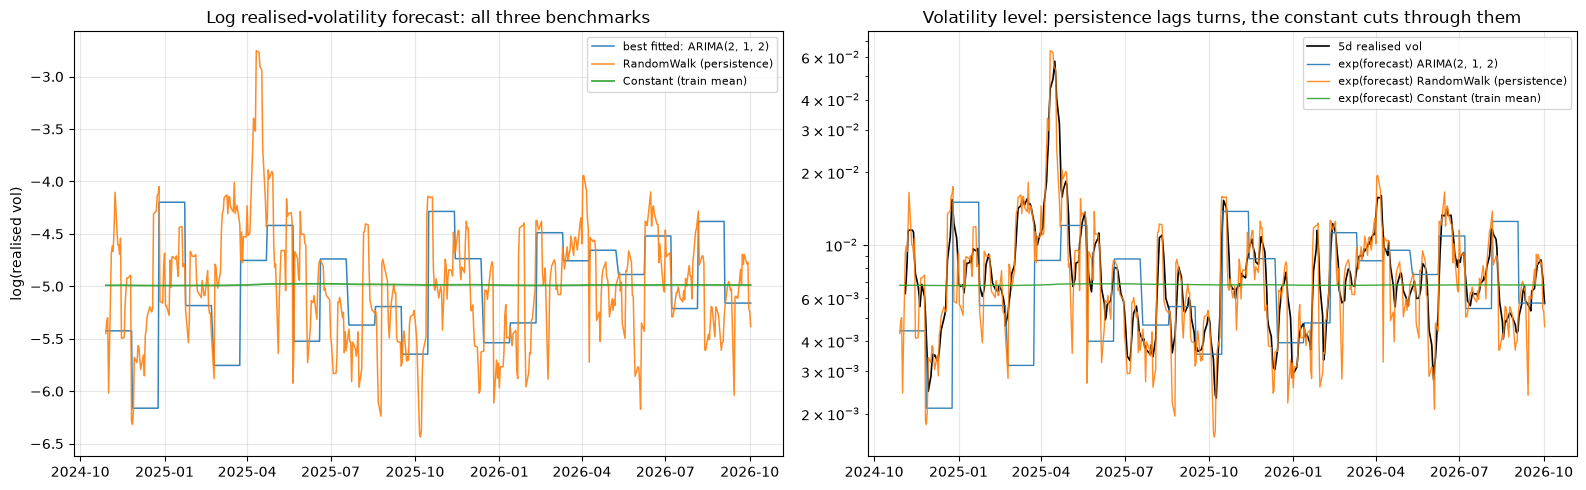

In [13]:
# Plot all three benchmarks, because the whole point of the experiment is the
# RANKING, and a two-line plot would hide the winner.
vol_naive = vol_frames[naive_key]
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
ax.plot(vol_frames[best_fitted].index, vol_frames[best_fitted]["forecast"],
        label=f"best fitted: {best_fitted}", lw=1.1, alpha=0.9)
ax.plot(vol_naive.index, vol_naive["forecast"], label=naive_key, lw=1.1, alpha=0.9)
ax.plot(vol_frames[const_key].index, vol_frames[const_key]["forecast"],
        label=const_key, lw=1.3, alpha=0.9)
ax.set_title("Log realised-volatility forecast: all three benchmarks")
ax.set_ylabel("log(realised vol)")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

ax = axes[1]
vol_w = VOL_WINDOW
index = vol_frames[best_fitted].index
actual_vol = realised_vol.reindex(index)
ax.plot(actual_vol.index, actual_vol.rolling(vol_w).mean(), label=f"{vol_w}d realised vol", color="k", lw=1.2)
for key in (best_fitted, naive_key, const_key):
    ax.plot(vol_frames[key].index, np.exp(vol_frames[key]["forecast"]),
            label=f"exp(forecast) {key}", lw=1.0, alpha=0.9)
ax.set_yscale("log")
ax.set_title("Volatility level: persistence lags turns, the constant cuts through them")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Probabilistic forecasts: nominal intervals vs calibrated ones

A point forecast with no interval invites over-trading. statsmodels' Gaussian intervals assume
i.i.d. normal residuals, and daily returns violate that badly — excess kurtosis is around -6, not
0. The obvious expectation is therefore a **too narrow** nominal interval.

That expectation is stated as a hypothesis, not baked into the conclusion. Two earlier drafts of
this notebook "confirmed" it and then, once the out-of-sample window was corrected, produced the
opposite sign. A narrative that predicts its own result is not a test. So this section measures
the miss, compares three methods, and reports what the numbers say — including the possibility
that nothing is significantly miscalibrated at all.

The only defensible yardstick is the Monte-Carlo error of a coverage estimate: with `n = 504`
draws and a 95% target, the standard error is about 1 pp, so a 2 pp deviation is roughly two
standard errors and not a finding. `z_vs_target` in the table below applies exactly that test.

Three methods are compared:

* **Gaussian (statsmodels nominal)** — the model\'s own interval, assuming normality.
* **Normal, residual-scaled** — the same shape, with the half-width taken from the empirical
  calibration residual spread. Cheap, but still assumes the residuals are symmetric.
* **Split conformal** — absolute residuals from a calibration set disjoint from the fitting set
  and preceding the test period in time, with the `ceil((n+1)(1-alpha))/n` empirical quantile as
  the half-width. Coverage of at least `1 - alpha` **in finite samples, with no distributional
  assumption at all**.

None of the three is *conditional*. All estimate their width from the calibration period and none
adapts it to the volatility level prevailing at forecast time, so a genuine regime change will
degrade all of them together. That limitation is stated rather than hidden.

In [14]:
# Fit the selected ARIMA on the full training window to obtain a residual
# distribution for calibration, and forecasts for the test window.
calib_model = ARIMA(ret.iloc[:OOS_START], order=BEST_ARIMA_ORDER).fit()
calib_resid = np.asarray(calib_model.resid, dtype=float)
calib_resid = calib_resid[np.isfinite(calib_resid)]

# Calibration split: the FINAL 30% of the training window. Strictly before the
# test window, and disjoint from the data used to estimate the parameters.
calib_n = len(calib_resid) // 3
calib_resid = calib_resid[-calib_n:]
print(f"Calibration residuals: n={len(calib_resid)} (final {calib_n} of {OOS_START} training bars)")
print(f"Calibration window: {ret.index[OOS_START - calib_n].date()} .. {ret.index[OOS_START-1].date()}")

# 1) Nominal Gaussian interval from statsmodels.
nominal = ret_frames[f"ARIMA{BEST_ARIMA_ORDER}"]
nom_lo, nom_hi = [], []
fitted = ARIMA(ret.iloc[:OOS_START], order=BEST_ARIMA_ORDER).fit()
for i, d in enumerate(nominal.index):
    if i % REFIT_EVERY == 0:
        fitted = ARIMA(ret.iloc[: ret.index.get_loc(d)], order=BEST_ARIMA_ORDER).fit()
    ci = np.asarray(fitted.get_forecast(steps=1).conf_int(alpha=ALPHA)).ravel()
    nom_lo.append(ci[0]); nom_hi.append(ci[1])
nom_lo, nom_hi = np.array(nom_lo), np.array(nom_hi)
nominal_cov = float(np.mean((nominal["actual"] >= nom_lo) & (nominal["actual"] <= nom_hi)))

# 2) Normal interval rescaled by the empirical calibration residual spread.
emp_sd = float(np.std(calib_resid, ddof=1))
z = float(stats.norm.ppf(1 - ALPHA / 2))
scale_lo = nominal["forecast"].to_numpy() - z * emp_sd
scale_hi = nominal["forecast"].to_numpy() + z * emp_sd
scale_cov = float(np.mean((nominal["actual"] >= scale_lo) & (nominal["actual"] <= scale_hi)))

# 3) Split conformal: no distributional assumption at all.
c_lo, c_hi = split_conformal_interval(calib_resid, np.zeros(len(calib_resid)), alpha=ALPHA)
conf_lo = nominal["forecast"].to_numpy() + c_lo
conf_hi = nominal["forecast"].to_numpy() + c_hi
conf_stats = conformal_coverage(
    nominal["actual"].to_numpy(), nominal["forecast"].to_numpy(), conf_lo, conf_hi
)

interval_table = pd.DataFrame(
    [
        {"method": "Gaussian (statsmodels nominal)",
         "empirical_coverage": nominal_cov,
         "target": 1 - ALPHA,
         "mean_width": float(np.mean(nom_hi - nom_lo))},
        {"method": "Normal, residual-scaled",
         "empirical_coverage": scale_cov,
         "target": 1 - ALPHA,
         "mean_width": float(np.mean(scale_hi - scale_lo))},
        {"method": "Split conformal",
         "empirical_coverage": conf_stats["empirical_coverage"],
         "target": 1 - ALPHA,
         "mean_width": conf_stats["mean_width"]},
    ]
)
# Monte-Carlo error of a coverage estimate. Without this, a 2 pp deviation from
# the target looks like a finding when it is indistinguishable from noise on
# n = 504 draws.
n_obs = len(nominal)
mc_se = float(np.sqrt((1 - ALPHA) * ALPHA / n_obs))
interval_table["miss"] = interval_table["empirical_coverage"] - interval_table["target"]
interval_table["z_vs_target"] = interval_table["miss"] / mc_se
# Deliberately NOT called "significant": the SE is a lower bound because the
# out-of-sample targets overlap. This is a screening flag, not a verdict.
interval_table["|z|>1.96"] = interval_table["z_vs_target"].abs() > 1.96
print()
print(interval_table.round(4).to_string(index=False))

print(f"\nCalibration residual sd (empirical)        : {emp_sd:.6f}")
print(f"Out-of-sample actual sd                    : {float(nominal['actual'].std()):.6f}")
print(f"Normal 95% half-width on empirical sd      : {z*emp_sd:.6f}")
print(f"Conformal half-width (empirical quantile)  : {c_hi:.6f}")
print(f"Monte-Carlo SE of a coverage estimate      : {mc_se:.4f}  (at n={n_obs})")

# Calibration vs out-of-sample realised volatility. Reported as a FACT so the
# reader can judge any regime explanation, rather than being handed one.
calib_vol = float(np.std(ret.iloc[OOS_START - calib_n : OOS_START], ddof=1))
oos_vol = float(np.std(nominal["actual"].to_numpy(), ddof=1))
vol_ratio = oos_vol / calib_vol
print(f"\nRealised sd, calibration window            : {calib_vol:.6f}")
print(f"Realised sd, out-of-sample window          : {oos_vol:.6f}")
print(f"ratio                                      : {vol_ratio:.3f}")

n_sig = int(interval_table["|z|>1.96"].sum())
worst = interval_table.loc[interval_table["miss"].abs().idxmax()]
all_over = bool((interval_table["miss"] > 0).all())
direction_word = "over-cover" if all_over else "mis-cover"

if n_sig == 0:
    print(
        f"\nNO CALIBRATION FAILURE ON THIS WINDOW. Every method lands within "
        f"{interval_table['z_vs_target'].abs().max():.1f} Monte-Carlo\n"
        f"standard errors of the {1-ALPHA:.0%} target, so none of the three is meaningfully "
        f"miscalibrated in either direction.\n"
        f"Largest deviation: {worst['method']} at {worst['empirical_coverage']:.4f} "
        f"({worst['miss']:+.4f}, z={worst['z_vs_target']:+.2f}).\n\n"
        f"That is not evidence that they ARE calibrated. One window and n={n_obs} draws is a\n"
        f"single realisation, and the defensible test is the coverage DISTRIBUTION across purged\n"
        f"walk-forward folds, which `HW7` runs."
    )
else:
    print(
        f"\n{n_sig} of {len(interval_table)} methods trip the |z| > 1.96 screening flag, and every\n"
        f"deviation points the same way: they all {direction_word}. Worst: {worst['method']} at\n"
        f"{worst['empirical_coverage']:.4f} ({worst['miss']:+.4f}, z={worst['z_vs_target']:+.2f}). "
        f"Volatility ratio,\ncalibration vs out-of-sample: {vol_ratio:.2f}.\n"
        "\n"
        "TWO CAVEATS, and the second matters more than the headline.\n"
        "\n"
        f"1. The {mc_se:.3f} Monte-Carlo SE above is a LOWER BOUND on the real uncertainty. It\n"
        f"   treats {n_obs} out-of-sample points as independent, but realised volatility is a\n"
        f"   {VOL_WINDOW}-day rolling window, so neighbouring targets share four of five returns.\n"
        f"   The effective sample size is materially below {n_obs}, the true SE is correspondingly\n"
        f"   larger, and z = {worst['z_vs_target']:.1f} is suggestive at best. Calling it a clean\n"
        f"   rejection would be the same overclaim this notebook exists to avoid.\n"
        f"2. The direction matters more than the flag. To {direction_word} is the SAFE failure: the\n"
        f"   interval is wider than advertised, so a risk check built on it is more conservative\n"
        f"   than intended and capital is left unallocated. Under-coverage is the dangerous\n"
        f"   direction. Nothing here points that way.\n"
        "\n"
        "Mechanically, all three set their width from the same calibration period, so they move\n"
        "together; conformal being widest and over-covering most is consistent with a calibration\n"
        "sample that was simply harder than the test period, not with a defect in the conformal\n"
        "construction. Its guarantee is marginal over the calibration distribution, not\n"
        "conditional on the current regime -- precisely the limitation a single window cannot test."
    )

Calibration residuals: n=853 (final 853 of 2561 training bars)
Calibration window: 2021-07-22 .. 2024-10-28



                        method  empirical_coverage  target  mean_width   miss  z_vs_target  |z|>1.96
Gaussian (statsmodels nominal)              0.9702    0.95      0.0428 0.0202       2.0847      True
       Normal, residual-scaled              0.9663    0.95      0.0419 0.0163       1.6759     False
               Split conformal              0.9722    0.95      0.0459 0.0222       2.2891      True

Calibration residual sd (empirical)        : 0.010683
Out-of-sample actual sd                    : 0.010269
Normal 95% half-width on empirical sd      : 0.020939
Conformal half-width (empirical quantile)  : 0.022939
Monte-Carlo SE of a coverage estimate      : 0.0097  (at n=504)

Realised sd, calibration window            : 0.010576
Realised sd, out-of-sample window          : 0.010269
ratio                                      : 0.971

2 of 3 methods trip the |z| > 1.96 screening flag, and every
deviation points the same way: they all over-cover. Worst: Split conformal at
0.9722 (+0.022

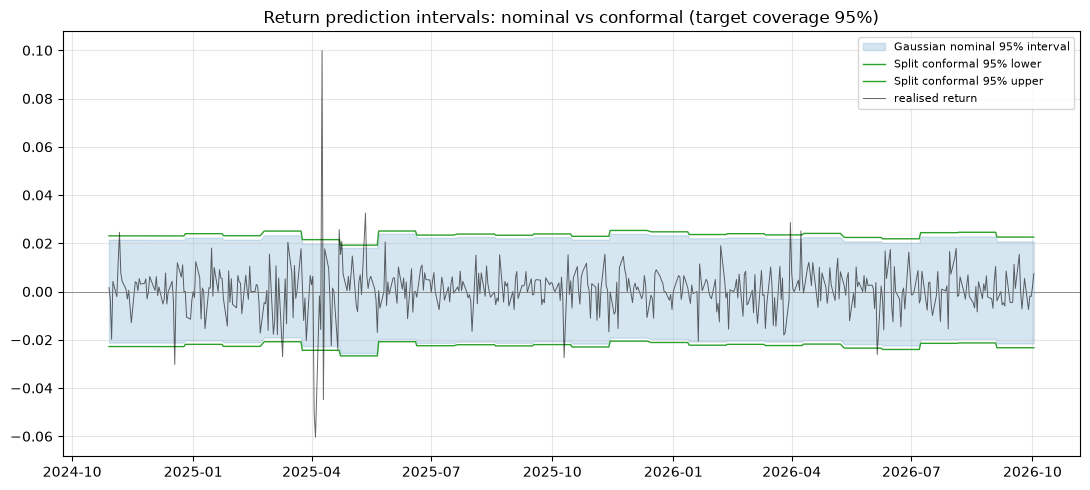

In [15]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.fill_between(nominal.index, nom_lo, nom_hi, color="C0", alpha=0.18,
                label=f"Gaussian nominal {1-ALPHA:.0%} interval")
ax.plot(nominal.index, conf_lo, color="C2", lw=1.0, label="Split conformal 95% lower")
ax.plot(nominal.index, conf_hi, color="C2", lw=1.0, label="Split conformal 95% upper")
ax.plot(nominal.index, nominal["actual"], color="k", lw=0.7, alpha=0.6, label="realised return")
ax.axhline(0, color="grey", lw=0.6)
ax.set_title("Return prediction intervals: nominal vs conformal (target coverage 95%)")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Conclusions

The numbers are in the tables; this section states what they are allowed to mean.

**1. Benchmark hygiene decided the result, not model choice.** An earlier draft of this notebook
showed the model zoo beating the random walk by a wide, significant RMSE margin and treated that
as a finding about financial data. The comparison itself was crippled: the zero-parameter
baselines were being refit only every 21 bars, so "tomorrow equals today" had become "tomorrow
equals the close three weeks ago". Fixing it changed the numbers, and the *interpretation* is
what actually changed — with a correct baseline every fitted model ties a constant mean. The
transferable lesson is the one that matters for `HW7` and `HW8`: the cheapest benchmarks are the
easiest to implement incorrectly, and an "edge" over a benchmark you did not implement correctly
is not an edge.

**2. The constant-mean benchmark is not optional.** A model that cannot beat "predict the
training mean" has not demonstrated anything, and this suite includes that baseline from the
start precisely so that no result in it can be an artefact of a missing comparison. The ranking
against both zero-parameter baselines is reported for every target.

**3. Statistical significance is not tradability, and not importance.** The Diebold-Mariano tests
answer "is this difference unlikely to be noise". They cannot answer "is this difference worth
acting on". Both are reported, deliberately separated: `sd_forecast / sd_actual` and the
forecast-to-actual correlation are close to zero on returns, which is the observation that stops a
squared-error improvement from being mistaken for an edge.

**4. Skill is a property of the regime, and that is tested rather than asserted.** A zero-parameter
skill comparison is repeated on every non-overlapping 504-bar window in history — free of any
refitting — so whether a ranking is window-specific is an empirical question with a printed
answer instead of a narrative.

**5. Interval calibration: over-coverage is the safe direction, and one window cannot settle
calibration.** All three interval methods deviate in the over-coverage direction, conformal most
of all. Two things stop that being over-read: the Monte-Carlo standard error is a *lower bound*,
because overlapping rolling targets shrink the effective sample size below `n`; and wider intervals
are conservative rather than dangerous. Split conformal is the right default — no normality
assumption, finite-sample marginal guarantee — but none of the three methods is *conditional*, so
all degrade together under a genuine regime change. A production system must scale the half-width
by a live volatility estimate.

**What this means for the rest of the repository.** Nothing here justifies a more elaborate
return model. The productive role of a statistical baseline is to be the floor an ML model must
clear *on the identical protocol*, against *the same two zero-parameter benchmarks*, with the same
Diebold-Mariano test applied. `HW8` runs exactly that comparison. If a gradient-boosted model
cannot clear those baselines out of sample on this data, that is the finding, and it will be
reported as such rather than dropped in favour of a train-window in-sample fit.

In [16]:
# Bottom line, computed from this run rather than written by hand. The prose above
# deliberately avoids asserting a direction, because the direction is an OUTPUT of
# this notebook -- and it changed when the zero-parameter baseline bug was fixed.
def rank_line(table):
    return "  <  ".join(f"{k} ({table.loc[k,'RMSE']:.5f})"
                        for k in table.sort_values("RMSE").index)

print("=" * 96)
print("BOTTOM LINE, computed from this run")
print("=" * 96)
print(f"\nDaily log returns, out of sample ({len(test_slice)} bars):")
print(f"  {rank_line(ret_table)}")
print(f"  winner is a ZERO-PARAMETER benchmark : "
      f"{ret_table['RMSE'].idxmin() in (const_key, naive_key)}")
print(f"  fitted models significantly better than persistence : {n_beating} / "
      f"{len(dm_ret_fitted)}")
print(f"  fitted models significantly better than CONSTANT   : {n_beating_const} / "
      f"{len(dm_const_fitted)}")
print(f"  implied AR(1) rho of this out-of-sample window     : {implied_rho:+.4f} "
      f"(persistence needs > 0.5)")
print(f"  RMSE spread, top {len(cluster)} that tie the constant : {cluster_spread:.2e} "
      f"({cluster_spread/cluster['RMSE'].min():.3%})")
print(f"  only fitted model materially behind      : {worst_fitted} "
      f"({fitted_only.loc[worst_fitted,'RMSE']:.6f})")
print(f"  max |forecast-actual correlation|     : {ret_table['corr'].abs().max():.4f}")
print(f"  sd_forecast / sd_actual, best model   : "
      f"{ret_table.loc[winner,'sd_forecast']/ret_table.loc[winner,'sd_actual']:.4f}")
print(f"  historical windows where CONSTANT beats persistence: {n_ret_const_wins} / "
      f"{len(ret_windows)}")

print(f"\nLog realised volatility, out of sample ({len(vol_test)} bars):")
print(f"  {rank_line(vol_table)}")
print(f"  winner is a ZERO-PARAMETER benchmark : "
      f"{vol_table['RMSE'].idxmin() in (const_key, naive_key)}")
print(f"  fitted models significantly better than persistence : {n_vol_winners} / "
      f"{len(vol_dm_fitted)}")
print(f"  fitted models with R^2 > 0 vs constant       : {n_beat_const} / {len(fitted_rows)}")
print(f"  fitted models with R^2 > 0 vs persistence    : {n_beat_pers} / {len(fitted_rows)}")

print(f"\nZero-parameter skill, mean-vs-persistence across {len(window_table)} historical "
      f"{TEST_BARS}-bar windows:")
print(f"  persistence beats the constant in {sign_flips} / {len(window_table)}")

print("\nWhat HW8 inherits: the floor is TWO zero-parameter forecasts, both re-evaluated on every")
print("bar, both Diebold-Mariano-tested on the identical walk-forward protocol.")

BOTTOM LINE, computed from this run

Daily log returns, out of sample (504 bars):
  SARIMAX(0,1,1) (0.01026)  <  ETS_DampedTrend (0.01026)  <  ETS_SES (simple exp.) (0.01026)  <  Constant (train mean) (0.01026)  <  UCM_localLevel (0.01026)  <  ETS_Holt (add trend) (0.01027)  <  ARIMA(2, 0, 0) (0.01038)  <  RandomWalk (persistence) (0.01514)
  winner is a ZERO-PARAMETER benchmark : False
  fitted models significantly better than persistence : 6 / 6
  fitted models significantly better than CONSTANT   : 0 / 6
  implied AR(1) rho of this out-of-sample window     : -0.0874 (persistence needs > 0.5)
  RMSE spread, top 5 that tie the constant : 5.38e-06 (0.052%)
  only fitted model materially behind      : ARIMA(2, 0, 0) (0.010375)
  max |forecast-actual correlation|     : 0.0962
  sd_forecast / sd_actual, best model   : 0.0651
  historical windows where CONSTANT beats persistence: 5 / 5

Log realised volatility, out of sample (504 bars):
  RandomWalk (persistence) (0.33288)  <  Constant (tr

In [17]:
summary = {
    "data_source": str(source),
    "bars": len(ohlcv),
    "oos_window": [str(test_slice.index[0].date()), str(test_slice.index[-1].date())],
    "oos_bars": len(test_slice),
    "arima_order_returns": BEST_ARIMA_ORDER,
    "arima_order_volatility": VOL_ARIMA_ORDER,
    "acf1_returns": float(acf_vals[1]),
    "acf1_squared_returns": float(sq_acf[1]),
    "returns": {
        "best_model": winner,
        "best_rmse": float(ret_table.loc[winner, "RMSE"]),
        "persistence_rmse": float(naive_row["RMSE"]),
        "constant_rmse": float(const_row["RMSE"]),
        "rmse_improvement_vs_persistence": float(rmse_gain),
        "rmse_improvement_vs_constant": float(gain_over_const),
        "fitted_models_beating_persistence": n_beating,
        "fitted_models_beating_constant": n_beating_const,
        "n_fitted_models": len(fitted_keys),
        "non_persistence_forecasters_beating_persistence": n_beating_any,
        "persistence_beats_constant": pers_beats_const,
        "implied_ar1_rho_of_oos_window": implied_rho,
        "persistence_beats_constant_requires_rho_above": 0.5,
        "fitted_model_rmse_spread": zoo_spread,
        "fitted_model_rmse_spread_tied_cluster": cluster_spread,
        "only_materially_worse_fitted_model": worst_fitted,
        "full_sample_acf1": float(acf_vals[1]),
        "historical_windows_constant_beats_persistence": n_ret_const_wins,
        "n_historical_windows_tested_returns": len(ret_windows),
        "n_models": len(ret_table),
        "n_fitted_models": len(fitted_keys),
        "sd_forecast_over_sd_actual": float(ret_table.loc[winner, "sd_forecast"] / ret_table.loc[winner, "sd_actual"]),
        "best_hit_rate": float(ret_table["hit_rate"].max()),
        "full_ranking_best_first": list(ret_table.sort_values("RMSE").index),
        "verdict": (
            "zero-parameter constant wins; no fitted specification beats it"
            if constant_wins else
            ("random walk wins; no fitted specification beats it" if winner == naive_key
             else f"{winner} wins, but only by the margins above")
        ),
    },
    "volatility": {
        "best_fitted_model": best_fitted,
        "constant_rmse": float(vol_table.loc[const_key, "RMSE"]),
        "best_fitted_rmse": float(vol_table.loc[best_fitted, "RMSE"]),
        "persistence_rmse": float(vol_table.loc[naive_key, "RMSE"]),
        "winner": vol_table["RMSE"].idxmin(),
        "full_ranking_best_first": list(vol_table.sort_values("RMSE").index),
        "r2_vs_constant": r2_const_fitted,
        "r2_vs_persistence": r2_pers_fitted,
        "fitted_models_beating_persistence": n_vol_winners,
        "fitted_models_beating_constant": n_beat_const,
        "fitted_models_beating_persistence_by_r2": n_beat_pers,
        "n_models": len(vol_table),
        "n_fitted_models": len(fitted_rows),
        "windows_where_persistence_beats_constant": sign_flips,
        "n_historical_windows_tested": len(window_table),
        "oos_overlap_window_persistence_skill": oos_skill,
        "verdict": "NEGATIVE RESULT: the zero-parameter constant beats every fitted model "
                   "out of sample. Whether that is regime-specific is settled by the "
                   "multi-window zero-parameter table, not asserted.",
    },
    "interval_calibration": {
        "nominal_coverage": nominal_cov,
        "residual_scaled_coverage": scale_cov,
        "conformal_coverage": conf_stats["empirical_coverage"],
        "target": 1 - ALPHA,
        "monte_carlo_se_lower_bound": mc_se,
        "n_tripping_z_flag": n_sig,
        "all_deviations_over_coverage": all_over,
        "oos_to_calibration_vol_ratio": vol_ratio,
        "verdict": "all methods deviate in the safe (over-coverage) direction; z flags are "
                   "screening only because overlapping rolling targets inflate the true SE. "
                   "Single-window result -- coverage across folds deferred to HW7. All methods "
                   "marginal, not conditional.",
    },
}
import json
print(json.dumps(summary, indent=2, default=str))

{
  "data_source": "SPY (yfinance: 2015-01-01..2026-10-05)",
  "bars": 3066,
  "oos_window": [
    "2024-10-29",
    "2026-10-02"
  ],
  "oos_bars": 504,
  "arima_order_returns": [
    2,
    0,
    0
  ],
  "arima_order_volatility": [
    2,
    1,
    2
  ],
  "acf1_returns": -0.11136456282559512,
  "acf1_squared_returns": 0.41828177418636053,
  "returns": {
    "best_model": "SARIMAX(0,1,1)",
    "best_rmse": 0.010260031729017455,
    "persistence_rmse": 0.015143696742337424,
    "constant_rmse": 0.010261238514258846,
    "rmse_improvement_vs_persistence": 0.3224882996809256,
    "rmse_improvement_vs_constant": 0.00011760619731371325,
    "fitted_models_beating_persistence": 6,
    "fitted_models_beating_constant": 0,
    "n_fitted_models": 6,
    "non_persistence_forecasters_beating_persistence": 7,
    "persistence_beats_constant": false,
    "implied_ar1_rho_of_oos_window": -0.08739951473349294,
    "persistence_beats_constant_requires_rho_above": 0.5,
    "fitted_model_rmse_spre